# BBC test — BERT-Large (no fine-tuning)

Frozen **`bert-large-uncased`**: encode test documents and label prototypes with the pretrained backbone; **cosine similarity** picks the label (encoder-only zero-shot, analogous to no-training eval).

**Metrics** (same core set as `bbc_GPT2_355M` zero-shot): `classification_metrics` → accuracy, macro F1, weighted F1; plus full `classification_report` and confusion matrix.

**Timing**: wall-clock for model load, encoding/inference, and total; peak GPU allocation when CUDA is available.

In [14]:
import copy
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, BertModel

import warnings

_ROOT = Path("..").resolve()
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from llm_doc_classification.config import (
    bbc_data_dir,
    config_path_display,
    get_seed,
    load_config,
    paths,
)
from llm_doc_classification.data.bbc import (
    BBC_LABELS,
    bbc_label_maps,
    clean_bbc_splits,
    load_bbc_split,
    raw_dataset_dict_from_bbc_frames,
)
from llm_doc_classification.models.gpt2_bbc_generative import classification_metrics
from llm_doc_classification.utils.seed import set_seed_all

In [ ]:
# BBC splits (evaluate on test only)
DATA_ROOT = bbc_data_dir()
label2id, id2label = bbc_label_maps()
train_df = load_bbc_split(DATA_ROOT, "train")
val_df = load_bbc_split(DATA_ROOT, "val")
test_df = load_bbc_split(DATA_ROOT, "test")
train_df, val_df, test_df = clean_bbc_splits(
    train_df, val_df, test_df, label2id=label2id
)
LABELS = list(BBC_LABELS)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("Label mapping:", label2id)
_ = raw_dataset_dict_from_bbc_frames(train_df, val_df, test_df)
print("Config:", config_path_display())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Loaded train from train.csv (no train/ folder found)
Loaded val from val.csv (no val/ folder found)
Loaded test from test.csv (no test/ folder found)
Train: 1780, Val: 222, Test: 223
Label mapping: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Config: D:\Projects\llm_doc_classification\configs\default.json
Device: cuda


In [ ]:
# BERT-Large — same max_length as `bert` section unless overridden
MODEL_NAME = "bert-large-uncased"
_BERT = load_config()["bert"]
MAX_LENGTH = int(_BERT["max_length"])
BATCH_SIZE = 8
SEED = get_seed()
set_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Full template per label gives stabler prototypes than a single class name.
LABEL_PROTOTYPES = [f"This BBC news article is about {lab}." for lab in LABELS]

In [ ]:
@torch.inference_mode()
def bert_cls_pooler_embeddings(
    model: AutoModel,
    tokenizer,
    texts: list[str],
    *,
    device: torch.device,
    max_length: int,
    batch_size: int,
    show_progress: bool = True,
) -> torch.Tensor:
    """CLS pooler output (768-d for base; 1024-d for large), L2-normalized per row."""
    model.eval()
    out_list: list[torch.Tensor] = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start : start + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        pool = model(**enc).pooler_output
        out_list.append(pool)
        if show_progress and (start // batch_size) % 25 == 0:
            print(f"  encoded {min(start + batch_size, n)} / {n}")
    stacked = torch.cat(out_list, dim=0)
    return F.normalize(stacked, dim=-1)


t_total0 = perf_counter()

t_load0 = perf_counter()
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
for p in model.parameters():
    p.requires_grad = False
t_load = perf_counter() - t_load0

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_inf0 = perf_counter()
label_emb = bert_cls_pooler_embeddings(
    model,
    tokenizer,
    LABEL_PROTOTYPES,
    device=device,
    max_length=min(64, MAX_LENGTH),
    batch_size=len(LABEL_PROTOTYPES),
    show_progress=False,
)

doc_emb = bert_cls_pooler_embeddings(
    model,
    tokenizer,
    test_df["text"].tolist(),
    device=device,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    show_progress=True,
)

scores = doc_emb @ label_emb.T
pred_ids = scores.argmax(dim=-1).cpu().numpy().tolist()
y_pred = [id2label[i] for i in pred_ids]
y_true = test_df["label"].tolist()

if torch.cuda.is_available():
    torch.cuda.synchronize()
t_inf = perf_counter() - t_inf0
t_total = perf_counter() - t_total0

peak_gb = None
if torch.cuda.is_available():
    peak_gb = torch.cuda.max_memory_allocated() / (1024**3)

print(f"\nBERT-Large ({MODEL_NAME}) — no fine-tuning, prototype similarity")
print(f"  model load time: {t_load:.2f}s")
print(f"  inference time (prototypes + {len(test_df)} docs): {t_inf:.2f}s")
print(f"  total wall time: {t_total:.2f}s")
if peak_gb is not None:
    print(f"  peak GPU memory (allocated): {peak_gb:.2f} GB")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

d:\Projects\llm_doc_classification\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aram_\.cache\huggingface\hub\models--bert-large-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  encoded 8 / 223
  encoded 208 / 223

BERT-Large (bert-large-uncased) — no fine-tuning, prototype similarity
  model load time: 62.37s
  inference time (prototypes + 223 docs): 15.92s
  total wall time: 78.29s
  peak GPU memory (allocated): 1.43 GB


In [5]:
metrics = classification_metrics(y_true, y_pred, labels=LABELS)

print("\nCore metrics (same keys as GPT-2 355M zero-shot)")
print(f"  accuracy:    {metrics['accuracy']:.4f}")
print(f"  macro_f1:    {metrics['macro_f1']:.4f}")
print(f"  weighted_f1: {metrics['weighted_f1']:.4f}")

print("\nClassification report (test)")
print(classification_report(y_true, y_pred, labels=LABELS, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
print("Confusion matrix (rows=true, cols=pred)")
print(cm)


Core metrics (same keys as GPT-2 355M zero-shot)
  accuracy:    0.2242
  macro_f1:    0.0741
  weighted_f1: 0.0847

Classification report (test)
               precision    recall  f1-score   support

     business     0.0000    0.0000    0.0000        51
entertainment     0.0000    0.0000    0.0000        39
     politics     0.0000    0.0000    0.0000        42
        sport     0.2283    0.9804    0.3704        51
         tech     0.0000    0.0000    0.0000        40

     accuracy                         0.2242       223
    macro avg     0.0457    0.1961    0.0741       223
 weighted avg     0.0522    0.2242    0.0847       223

Confusion matrix (rows=true, cols=pred)
[[ 0  0  1 50  0]
 [ 0  0  1 37  1]
 [ 0  0  0 42  0]
 [ 0  0  1 50  0]
 [ 0  0  0 40  0]]


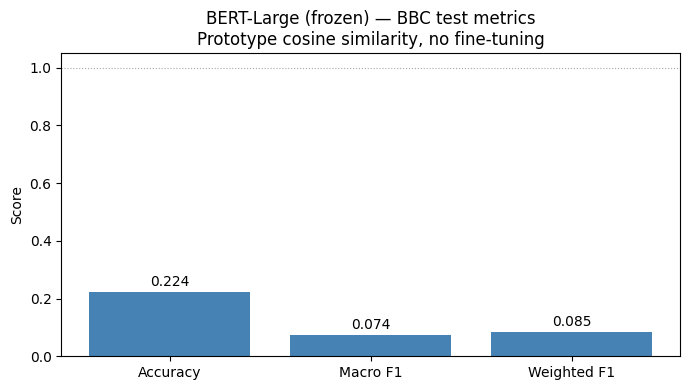

In [6]:
metric_keys = ["accuracy", "macro_f1", "weighted_f1"]
vals = [float(metrics[k]) for k in metric_keys]
x_labels = ["Accuracy", "Macro F1", "Weighted F1"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, vals, color="steelblue")
ax.set_ylabel("Score")
ax.set_title("BERT-Large (frozen) — BBC test metrics\nPrototype cosine similarity, no fine-tuning")
ax.set_ylim(0, 1.05)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
fig.tight_layout()
plt.show()

## Fine-tuning BERT-Large on BBC

Train **3 epochs** with **AdamW** (`weight_decay=0.01` for regularization), **early stop on checkpoint selection** via **best validation loss** (lowest `val_loss` wins; after training, reload that checkpoint).

Each epoch logs **wall time**, **train loss / train accuracy**, **validation loss / accuracy / macro F1 / weighted F1** (same scalar trio as GPT‑355M), full **validation `classification_report`**, and **GPU memory** when CUDA is available.


In [15]:
# --- Fine-tune BERT-Large: 3 epochs, keep best checkpoint by validation loss ---
from llm_doc_classification.config import paths

for _name in ("model", "label_emb", "doc_emb", "scores"):
    if _name in globals():
        del globals()[_name]
if torch.cuda.is_available():
    torch.cuda.empty_cache()

raw_datasets = raw_dataset_dict_from_bbc_frames(train_df, val_df, test_df)

_P = paths()
BEST_FT_PATH = _P["models"] / "bert_large_bbc_best.pt"
BEST_FT_PATH.parent.mkdir(parents=True, exist_ok=True)


class BertClassifier(nn.Module):
    def __init__(self, model_name: str, num_labels: int, dropout_prob: float = 0.1):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        x = out.last_hidden_state[:, 0, :]
        x = self.dropout(x)
        return self.classifier(x)


def format_for_classification(text: str) -> str:
    return f"Text: {text} [SEP] Label:"


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


def build_prompted_tokenized_datasets():
    prompted = raw_datasets.map(
        lambda b: {"text": [format_for_classification(t) for t in b["text"]]},
        batched=True,
    )
    tokenized = prompted.map(tokenize_batch, batched=True)
    return tokenized.rename_column("label_id", "labels")


def build_loader(tokenized, split_name: str, batch_size: int, shuffle: bool) -> DataLoader:
    ds = tokenized[split_name]
    cols = ["input_ids", "attention_mask", "labels"]
    if "token_type_ids" in ds.column_names:
        cols.insert(2, "token_type_ids")
    ds.set_format(type="torch", columns=cols)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate_loss_and_accuracy(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    running_loss = 0.0
    all_pred_ids = []
    all_true_ids = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            loss = criterion(logits, labels)
            running_loss += loss.item()
            pred_ids = torch.argmax(logits, dim=-1)
            all_pred_ids.append(pred_ids.cpu())
            all_true_ids.append(labels.cpu())
    all_pred_ids = torch.cat(all_pred_ids, dim=0).numpy()
    all_true_ids = torch.cat(all_true_ids, dim=0).numpy()
    return running_loss / len(loader), accuracy_score(all_true_ids, all_pred_ids), all_true_ids, all_pred_ids


num_labels = len(LABELS)
num_epochs = 3
learning_rate = 2e-5
weight_decay = 0.01
finetune_batch_size = 8

set_seed_all(SEED)
prompted_tokenized = build_prompted_tokenized_datasets()
train_loader = build_loader(prompted_tokenized, "train", finetune_batch_size, shuffle=True)
val_loader = build_loader(prompted_tokenized, "validation", finetune_batch_size, shuffle=False)

model = BertClassifier(MODEL_NAME, num_labels=num_labels, dropout_prob=0.1).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

best_val_loss = float("inf")
best_state_dict = None
best_epoch = 0

train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
val_macro_f1_history = []
val_weighted_f1_history = []

for epoch in range(1, num_epochs + 1):
    epoch_start = perf_counter()
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)
    for step, batch in enumerate(progress_bar, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        progress_bar.set_postfix(
            loss=f"{running_loss / step:.4f}",
            train_acc=f"{train_correct / train_total:.4f}",
        )

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total
    val_loss, val_acc, val_true_ids, val_pred_ids = evaluate_loss_and_accuracy(
        model, val_loader, criterion, device
    )
    y_val_true = [id2label[int(i)] for i in val_true_ids]
    y_val_pred = [id2label[int(i)] for i in val_pred_ids]
    val_cm = classification_metrics(y_val_true, y_val_pred, labels=LABELS)

    epoch_time = perf_counter() - epoch_start

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    val_macro_f1_history.append(val_cm["macro_f1"])
    val_weighted_f1_history.append(val_cm["weighted_f1"])

    print(
        f"Epoch {epoch}/{num_epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | "
        f"val_macro_f1: {val_cm['macro_f1']:.4f} | val_weighted_f1: {val_cm['weighted_f1']:.4f} | "
        f"time: {epoch_time:.1f}s"
    )

    if device.type == "cuda":
        al = torch.cuda.memory_allocated(device) / (1024**3)
        rs = torch.cuda.memory_reserved(device) / (1024**3)
        pk = torch.cuda.max_memory_allocated(device) / (1024**3)
        print(f"  GPU mem (GB) | allocated: {al:.3f} | reserved: {rs:.3f} | peak_allocated: {pk:.3f}")
    else:
        print("  GPU mem (GB) | N/A (CPU)")

    print("  Validation classification_report:")
    print(classification_report(y_val_true, y_val_pred, labels=LABELS, digits=4, zero_division=0))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        torch.save(best_state_dict, BEST_FT_PATH)
        print(f"  -> Saved new best to {BEST_FT_PATH} (val_loss={best_val_loss:.4f}, val_acc={val_acc:.4f})")

if best_state_dict is None:
    raise RuntimeError("No best checkpoint was saved.")

model.load_state_dict(best_state_dict)
model.eval()
print(f"\nLoaded best checkpoint: epoch {best_epoch}, val_loss={best_val_loss:.4f} ({BEST_FT_PATH})")


Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1780 [00:00<?, ? examples/s]

Map:   0%|          | 0/222 [00:00<?, ? examples/s]

...

Epoch 1/3 | train_loss: 0.2437 | train_acc: 0.9213 | val_loss: 0.0753 | val_acc: 0.9730 | val_macro_f1: 0.9729 | val_weighted_f1: 0.9727 | time: 3831.4s
  GPU mem (GB) | allocated: 5.001 | reserved: 10.412 | peak_allocated: 10.270
  Validation classification_report:
               precision    recall  f1-score   support

     business     0.9259    0.9804    0.9524        51
entertainment     1.0000    1.0000    1.0000        38
     politics     1.0000    0.8810    0.9367        42
        sport     1.0000    1.0000    1.0000        51
         tech     0.9524    1.0000    0.9756        40

     accuracy                         0.9730       222
    macro avg     0.9757    0.9723    0.9729       222
 weighted avg     0.9744    0.9730    0.9727       222

  -> Saved new best to D:\Projects\llm_doc_classification\models\bert_large_bbc_best.pt (val_loss=0.0753, val_acc=0.9730)


Epoch 2/3:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 2/3 | train_loss: 0.0344 | train_acc: 0.9893 | val_loss: 0.0474 | val_acc: 0.9865 | val_macro_f1: 0.9861 | val_weighted_f1: 0.9865 | time: 3835.1s
  GPU mem (GB) | allocated: 6.251 | reserved: 11.650 | peak_allocated: 11.519
  Validation classification_report:
               precision    recall  f1-score   support

     business     0.9623    1.0000    0.9808        51
entertainment     1.0000    1.0000    1.0000        38
     politics     1.0000    0.9762    0.9880        42
        sport     1.0000    1.0000    1.0000        51
         tech     0.9744    0.9500    0.9620        40

     accuracy                         0.9865       222
    macro avg     0.9873    0.9852    0.9861       222
 weighted avg     0.9867    0.9865    0.9865       222

  -> Saved new best to D:\Projects\llm_doc_classification\models\bert_large_bbc_best.pt (val_loss=0.0474, val_acc=0.9865)


Epoch 3/3:   0%|          | 0/223 [00:00<?, ?it/s]

Epoch 3/3 | train_loss: 0.0317 | train_acc: 0.9927 | val_loss: 0.0842 | val_acc: 0.9775 | val_macro_f1: 0.9780 | val_weighted_f1: 0.9775 | time: 3868.7s
  GPU mem (GB) | allocated: 6.251 | reserved: 11.650 | peak_allocated: 11.519
  Validation classification_report:
               precision    recall  f1-score   support

     business     1.0000    0.9216    0.9592        51
entertainment     1.0000    1.0000    1.0000        38
     politics     1.0000    0.9762    0.9880        42
        sport     0.9808    1.0000    0.9903        51
         tech     0.9091    1.0000    0.9524        40

     accuracy                         0.9775       222
    macro avg     0.9780    0.9796    0.9780       222
 weighted avg     0.9792    0.9775    0.9775       222


Loaded best checkpoint: epoch 2, val_loss=0.0474 (D:\Projects\llm_doc_classification\models\bert_large_bbc_best.pt)


In [16]:
# Test split — best BERT-Large checkpoint (timing + metrics)
test_loader = build_loader(prompted_tokenized, "test", finetune_batch_size, shuffle=False)

t0 = perf_counter()
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)

test_loss, test_acc_ids, all_true_ids, all_pred_ids = evaluate_loss_and_accuracy(
    model, test_loader, criterion, device
)

if device.type == "cuda":
    torch.cuda.synchronize()
test_eval_sec = perf_counter() - t0

y_true_ft = [id2label[int(i)] for i in all_true_ids]
y_pred_ft = [id2label[int(i)] for i in all_pred_ids]
ft_metrics = classification_metrics(y_true_ft, y_pred_ft, labels=LABELS)

print("BERT-Large (fine-tuned, best val-loss checkpoint) — BBC test")
print(f"  test_loss: {test_loss:.4f}")
print(f"  test accuracy (exact): {test_acc_ids:.4f}")
print(f"  accuracy:    {ft_metrics['accuracy']:.4f}")
print(f"  macro_f1:    {ft_metrics['macro_f1']:.4f}")
print(f"  weighted_f1: {ft_metrics['weighted_f1']:.4f}")
print(f"  eval wall time: {test_eval_sec:.2f}s")

if device.type == "cuda":
    pk = torch.cuda.max_memory_allocated(device) / (1024**3)
    print(f"  peak GPU allocated (eval): {pk:.3f} GB")

print("\nClassification report (test)")
print(classification_report(y_true_ft, y_pred_ft, labels=LABELS, digits=4, zero_division=0))

cm_ft = confusion_matrix(y_true_ft, y_pred_ft, labels=LABELS)
print("Confusion matrix (rows=true, cols=pred)")
print(cm_ft)


BERT-Large (fine-tuned, best val-loss checkpoint) — BBC test
  test_loss: 0.1286
  test accuracy (exact): 0.9731
  accuracy:    0.9731
  macro_f1:    0.9732
  weighted_f1: 0.9731
  eval wall time: 71.24s
  peak GPU allocated (eval): 6.424 GB

Classification report (test)
               precision    recall  f1-score   support

     business     0.9600    0.9412    0.9505        51
entertainment     1.0000    1.0000    1.0000        39
     politics     0.9130    1.0000    0.9545        42
        sport     1.0000    1.0000    1.0000        51
         tech     1.0000    0.9250    0.9610        40

     accuracy                         0.9731       223
    macro avg     0.9746    0.9732    0.9732       223
 weighted avg     0.9745    0.9731    0.9731       223

Confusion matrix (rows=true, cols=pred)
[[48  0  3  0  0]
 [ 0 39  0  0  0]
 [ 0  0 42  0  0]
 [ 0  0  0 51  0]
 [ 2  0  1  0 37]]


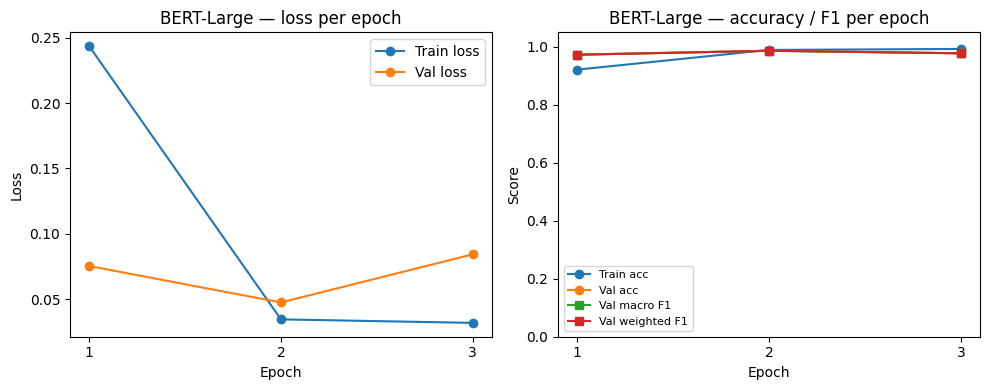

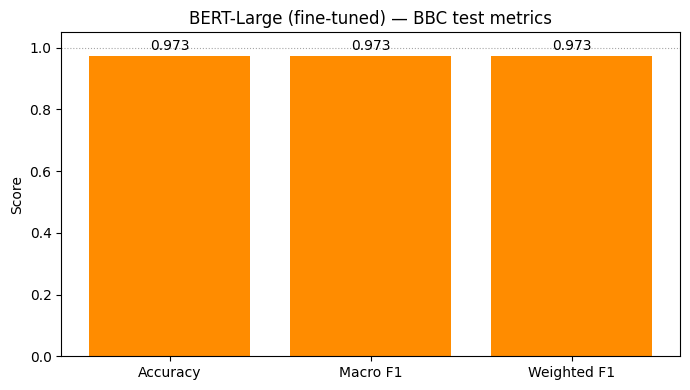

In [17]:
# Per-epoch training curves + test metric bar (fine-tuned)
epochs_axis = list(range(1, len(train_loss_history) + 1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1, ax2 = axes
ax1.plot(epochs_axis, train_loss_history, marker="o", label="Train loss")
ax1.plot(epochs_axis, val_loss_history, marker="o", label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("BERT-Large — loss per epoch")
ax1.legend()
ax1.set_xticks(epochs_axis)

ax2.plot(epochs_axis, train_acc_history, marker="o", label="Train acc")
ax2.plot(epochs_axis, val_acc_history, marker="o", label="Val acc")
ax2.plot(epochs_axis, val_macro_f1_history, marker="s", label="Val macro F1")
ax2.plot(epochs_axis, val_weighted_f1_history, marker="s", label="Val weighted F1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("BERT-Large — accuracy / F1 per epoch")
ax2.legend(fontsize=8)
ax2.set_xticks(epochs_axis)
ax2.set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

metric_keys = ["accuracy", "macro_f1", "weighted_f1"]
vals = [float(ft_metrics[k]) for k in metric_keys]
x_labels = ["Accuracy", "Macro F1", "Weighted F1"]
fig2, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, vals, color="darkorange")
ax.set_ylabel("Score")
ax.set_title("BERT-Large (fine-tuned) — BBC test metrics")
ax.set_ylim(0, 1.05)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
fig2.tight_layout()
plt.show()


In [ ]:
# --- Save best-by-val-loss bundle, then test on BBC test split (same weights) ---
import json

from llm_doc_classification.config import paths

if not BEST_FT_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {BEST_FT_PATH}. Run the fine-tuning cell first."
    )

MODEL_SAVE_DIR = paths()["models"] / "bert_large_bbc_best_bundle"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

try:
    sd = torch.load(BEST_FT_PATH, map_location=device, weights_only=True)
except TypeError:
    sd = torch.load(BEST_FT_PATH, map_location=device)
model.load_state_dict(sd)
model.eval()

bundle_path = MODEL_SAVE_DIR / "bert_large_bbc_best_state.pt"
torch.save(sd, bundle_path)

tokenizer.save_pretrained(MODEL_SAVE_DIR)

meta = {
    "model_name": MODEL_NAME,
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "max_length": int(MAX_LENGTH),
    "num_labels": int(num_labels),
    "label2id": label2id,
    "state_dict_file": bundle_path.name,
    "note": "Weights chosen by lowest validation loss during training, not necessarily the final epoch.",
}
with open(MODEL_SAVE_DIR / "train_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Saved best model artifacts to:", MODEL_SAVE_DIR)
print("  state dict:", bundle_path.name)
print("  tokenizer:  tokenizer files in same folder")
print("  metadata:   train_meta.json")


Saved best model artifacts to: D:\Projects\llm_doc_classification\models\bert_large_bbc_best_bundle
  state dict: bert_large_bbc_best_state.pt
  tokenizer:  tokenizer files in same folder
  metadata:   train_meta.json



BERT-Large (saved best checkpoint) — BBC test
  test_loss: 0.1286
  test accuracy (exact): 0.9731
  accuracy:    0.9731
  macro_f1:    0.9732
  weighted_f1: 0.9731
  eval wall time: 18.83s
  peak GPU allocated (eval): 7.674 GB

Classification report (test)
               precision    recall  f1-score   support

     business     0.9600    0.9412    0.9505        51
entertainment     1.0000    1.0000    1.0000        39
     politics     0.9130    1.0000    0.9545        42
        sport     1.0000    1.0000    1.0000        51
         tech     1.0000    0.9250    0.9610        40

     accuracy                         0.9731       223
    macro avg     0.9746    0.9732    0.9732       223
 weighted avg     0.9745    0.9731    0.9731       223

Confusion matrix (rows=true, cols=pred)
[[48  0  3  0  0]
 [ 0 39  0  0  0]
 [ 0  0 42  0  0]
 [ 0  0  0 51  0]
 [ 2  0  1  0 37]]


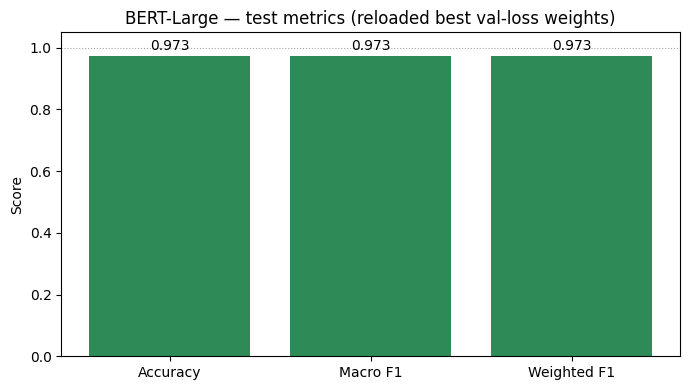

In [19]:
# --- Test split using reloaded best-by-val-loss weights ---
test_loader_saved = build_loader(
    prompted_tokenized, "test", finetune_batch_size, shuffle=False
)

t0 = perf_counter()
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)

ts_loss, ts_acc, ts_true_ids, ts_pred_ids = evaluate_loss_and_accuracy(
    model, test_loader_saved, criterion, device
)

if device.type == "cuda":
    torch.cuda.synchronize()
ts_eval_sec = perf_counter() - t0

y_true_saved = [id2label[int(i)] for i in ts_true_ids]
y_pred_saved = [id2label[int(i)] for i in ts_pred_ids]
saved_metrics = classification_metrics(y_true_saved, y_pred_saved, labels=LABELS)

print("\nBERT-Large (saved best checkpoint) — BBC test")
print(f"  test_loss: {ts_loss:.4f}")
print(f"  test accuracy (exact): {ts_acc:.4f}")
print(f"  accuracy:    {saved_metrics['accuracy']:.4f}")
print(f"  macro_f1:    {saved_metrics['macro_f1']:.4f}")
print(f"  weighted_f1: {saved_metrics['weighted_f1']:.4f}")
print(f"  eval wall time: {ts_eval_sec:.2f}s")

if device.type == "cuda":
    pk = torch.cuda.max_memory_allocated(device) / (1024**3)
    print(f"  peak GPU allocated (eval): {pk:.3f} GB")

print("\nClassification report (test)")
print(
    classification_report(
        y_true_saved, y_pred_saved, labels=LABELS, digits=4, zero_division=0
    )
)

cm_saved = confusion_matrix(y_true_saved, y_pred_saved, labels=LABELS)
print("Confusion matrix (rows=true, cols=pred)")
print(cm_saved)

mk = ["accuracy", "macro_f1", "weighted_f1"]
vs = [float(saved_metrics[k]) for k in mk]
xl = ["Accuracy", "Macro F1", "Weighted F1"]
fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.bar(xl, vs, color="seagreen")
ax3.set_ylabel("Score")
ax3.set_title("BERT-Large — test metrics (reloaded best val-loss weights)")
ax3.set_ylim(0, 1.05)
for i, v in enumerate(vs):
    ax3.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
ax3.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
fig3.tight_layout()
plt.show()
